In [2]:
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import scipy.stats as sp
from sklearn.neighbors import KernelDensity
from tqdm import tqdm

In [3]:
spin_sample = np.random.uniform(0, 1, size=1000)
M_sample = np.random.normal(loc=1, scale=0.02, size=1000)

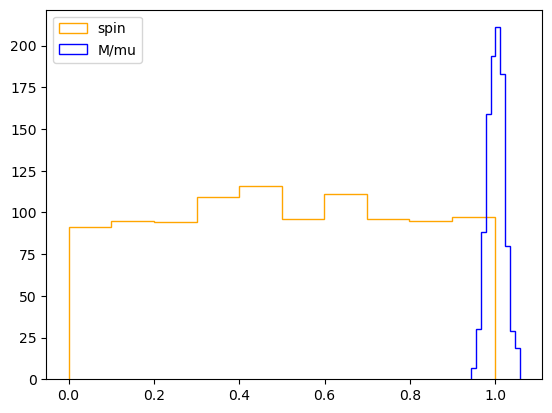

In [21]:
plt.hist(spin_sample, histtype='step', color='orange', label='spin')
plt.hist(M_sample, histtype='step', color='blue', label='M/mu')
plt.legend()

In [5]:
def calc_f(spin): return np.sqrt(0.5*(1+np.sqrt(1-spin**2)))

In [6]:
x = M_sample*calc_f(spin_sample)

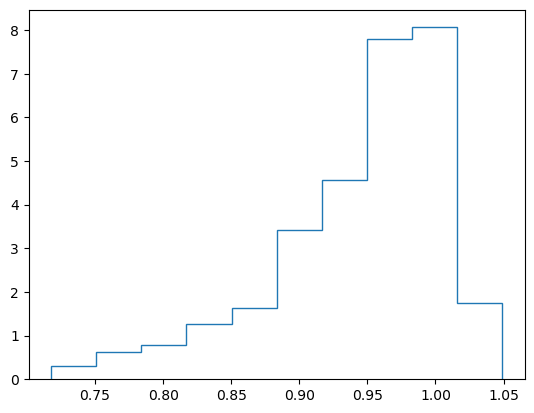

In [7]:
plt.hist(x, density=True, histtype='step')
plt.show()

In [ ]:
def kde_sklearn(data, bandwidth=1.0, kernel="linear", xgrid=np.linspace(0, 1, 1000)):
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

In [18]:
f_dist = calc_f(spin_sample)

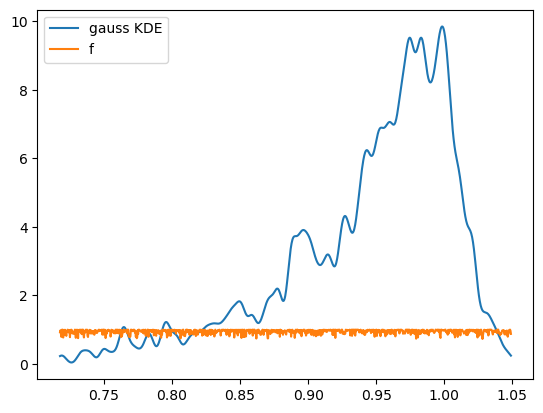

In [23]:
xgrid = np.linspace(x.min(), x.max(), 1000)
pdf_gauss = kde_sklearn(x, bandwidth=0.003, kernel='gaussian', xgrid=xgrid)
pdf_tophat = kde_sklearn(x, bandwidth=0.01, kernel='tophat', xgrid=xgrid)
plt.plot(xgrid, pdf_gauss, label='gauss KDE')
#plt.plot(xgrid, pdf_tophat, label='tophat kernel')
plt.plot(xgrid, f_dist, label='f')
plt.legend()
plt.show()

In [11]:
sigmas = np.linspace(0.0001, 0.15, 100)
pvalues = np.zeros((2,len(sigmas)))
for i in tqdm(range(len(sigmas))):
    pdf_gauss = kde_sklearn(x, bandwidth=sigmas[i], kernel='gaussian', xgrid=xgrid)
    pvalues[0,i] = np.array(sp.ks_2samp(pdf_gauss, f_dist).pvalue)
    pvalues[1,i] = np.array(sp.ks_2samp(pdf_gauss, M_sample).pvalue)

100%|██████████| 100/100 [00:06<00:00, 16.60it/s]


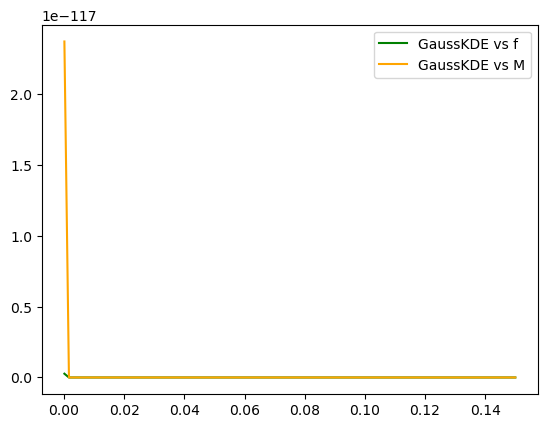

In [12]:
plt.plot(sigmas, pvalues[0], c='green', label='GaussKDE vs f')
plt.plot(sigmas, pvalues[1], c='orange', label='GaussKDE vs M')
#plt.yscale('log')
plt.legend()
plt.show()

In [13]:
print(sp.ks_2samp(pdf_gauss, f_dist).pvalue)
print(sp.ks_2samp(pdf_gauss, M_sample).pvalue)

0.0
0.0
